In [19]:
import warnings

import numpy as np
import matplotlib as plt
import pandas as pd
import sktime

from sktime.utils.plotting import plot_series
from sktime.split import TemporalTrainTestSplitter

# hide warnings
warnings.filterwarnings("ignore")

## Importing the dataset

In [2]:
df = pd.read_csv("GlobalTemperatures.csv", sep = ",")
df['dt'] = pd.to_datetime(df['dt'])
df.set_index("dt", inplace = True)
df.drop(['LandMaxTemperature', 'LandMaxTemperatureUncertainty',
       'LandMinTemperature', 'LandMinTemperatureUncertainty',
       'LandAndOceanAverageTemperature',
       'LandAndOceanAverageTemperatureUncertainty'], axis = 1, inplace = True)
df.head()

,LandAverageTemperature,LandAverageTemperatureUncertainty
dt,,
1750-01-01,3.034,3.574
1750-02-01,3.083,3.702
1750-03-01,5.626,3.076
1750-04-01,8.490,2.451
1750-05-01,11.573,2.072


## Handling missing values

In [3]:
missing_values = df.isnull().sum()
missing_values

LandAverageTemperature               12
LandAverageTemperatureUncertainty    12
dtype: int64

In [4]:
rows_with_missing = df[df.isnull().any(axis=1)]
rows_with_missing

,LandAverageTemperature,LandAverageTemperatureUncertainty
dt,,
1750-11-01,NaN,NaN
1751-05-01,NaN,NaN
1751-07-01,NaN,NaN
1751-10-01,NaN,NaN
1751-11-01,NaN,NaN
1751-12-01,NaN,NaN
1752-02-01,NaN,NaN
1752-05-01,NaN,NaN
1752-06-01,NaN,NaN


For simplicity we will only consider the values from 1800 also because they have a much lower uncertainity

(<Figure size 1600x400 with 1 Axes>,
 <Axes: ylabel='LandAverageTemperatureUncertainty'>)

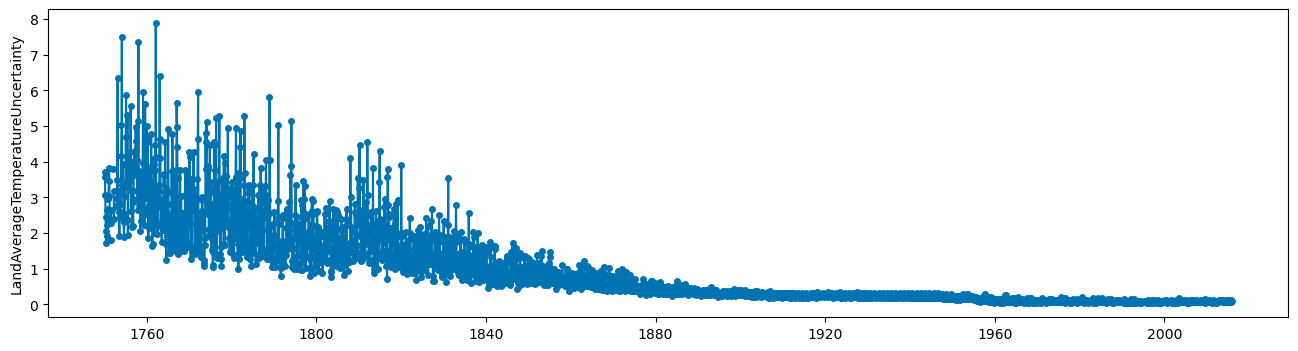

In [15]:
plot_series(df["LandAverageTemperatureUncertainty"])


In [10]:
df_filtered = df[df.index.year > 1800]
df_filtered

,LandAverageTemperature,LandAverageTemperatureUncertainty
1801-01-01,2.687,1.922
1801-02-01,3.149,2.045
1801-03-01,6.455,1.336
1801-04-01,7.404,1.619
1801-05-01,12.123,1.541
...,...,...
2015-08-01,14.755,0.072
2015-09-01,12.999,0.079
2015-10-01,10.801,0.102
2015-11-01,7.433,0.119


## Splitting the dataset into train and test


In [33]:
splitter = TemporalTrainTestSplitter(test_size=0.3)
train_indices, test_indices = next(splitter.split(df_filtered["LandAverageTemperature"]))
df_filtered_train = df_filtered.iloc[train_indices]
df_filtered_test = df_filtered.iloc[test_indices]

In [36]:
df_filtered_test

,LandAverageTemperature,LandAverageTemperatureUncertainty
1951-07-01,14.324,0.240
1951-08-01,14.021,0.251
1951-09-01,12.324,0.216
1951-10-01,9.670,0.123
1951-11-01,6.225,0.161
...,...,...
2015-08-01,14.755,0.072
2015-09-01,12.999,0.079
2015-10-01,10.801,0.102
2015-11-01,7.433,0.119


In [37]:
df_filtered_train

,LandAverageTemperature,LandAverageTemperatureUncertainty
1801-01-01,2.687,1.922
1801-02-01,3.149,2.045
1801-03-01,6.455,1.336
1801-04-01,7.404,1.619
1801-05-01,12.123,1.541
...,...,...
1951-02-01,2.332,0.149
1951-03-01,5.091,0.141
1951-04-01,8.367,0.175
1951-05-01,11.438,0.230


## Plots

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='LandAverageTemperature'>)

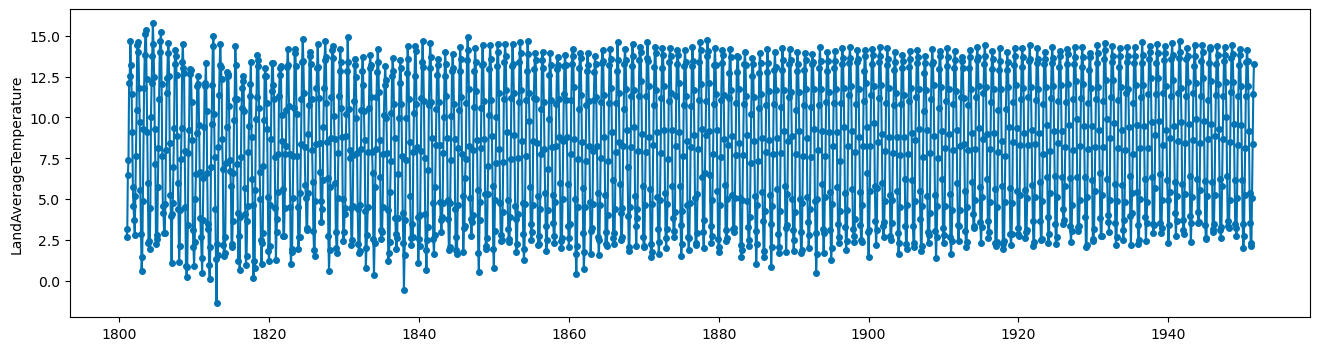

In [38]:
# Timeplot
plot_series(df_filtered_train["LandAverageTemperature"])